FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)

Konkavne vrcholy: 86
Mozne chody: 73
Maximalne parovanie: 42 parov
Maximalna nezavisla mnozina (MIS): 40 chord
Zvysne vrcholy pre Level 2: 18
Level 1 dokonceny: 40 rezov z MIS

FER ALGORITMUS - LEVEL 2 (NEAREST EDGE)

Zvysne vrcholy: 18

Spracovavam vrchol (276, 114)
  Rez: (276, 114) -> (263, 114) (horizontal, left, vzdialenost=13, pixle=12)

Spracovavam vrchol (277, 115)
  Rez: (277, 115) -> (263, 115) (horizontal, left, vzdialenost=14, pixle=13)

Spracovavam vrchol (279, 118)
  Rez: (279, 118) -> (264, 118) (horizontal, left, vzdialenost=15, pixle=14)

Spracovavam vrchol (295, 122)
  Rez: (295, 122) -> (268, 122) (horizontal, left, vzdialenost=27, pixle=26)

Spracovavam vrchol (303, 128)
  Rez: (303, 128) -> (274, 128) (horizontal, left, vzdialenost=29, pixle=28)

Spracovavam vrchol (306, 130)
  Rez: (306, 130) -> (275, 130) (horizontal, left, vzdialenost=31, pixle=30)

Spracovavam vrchol (311, 134)
  Rez: (311, 134) -> (279, 134) 

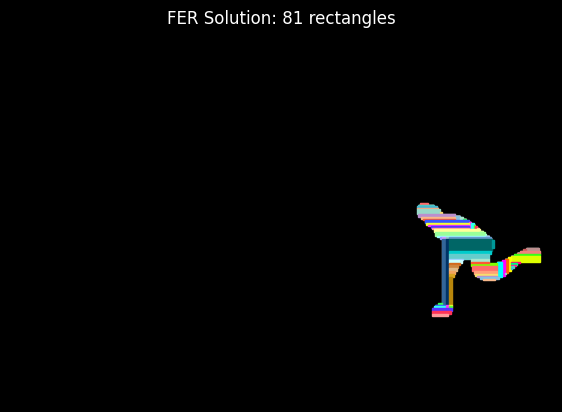

In [84]:
import numpy as np
from collections import defaultdict, deque
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle as MPLRectangle


# def visualize_fer_results(grid, concave_vertices, result, title_prefix=""):
#     fig, axes = plt.subplots(1, 3, figsize=(22, 8))
#     rows, cols = grid.shape
#
#     # AX1: Konkavne vrcholy
#     ax1 = axes[0]
#     for i in range(rows):
#         for j in range(cols):
#             color = 'lightblue' if grid[i, j] == 1 else 'white'
#             rect = MPLRectangle((j, i), 1, 1, linewidth=1,
#                             edgecolor='black' if grid[i, j] == 1 else 'gray',
#                             facecolor=color, alpha=0.7)
#             ax1.add_patch(rect)
#
#     for vertex in concave_vertices:
#         x, y = vertex
#         ax1.plot(x + 0.5, y + 0.5, 'ro', markersize=10, zorder=5)
#         ax1.text(x + 0.8, y + 0.2, f"({x},{y})", fontsize=8, fontweight='bold',
#                  color='darkred', bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
#
#     ax1.set_xlim(0, cols)
#     ax1.set_ylim(0, rows)
#     ax1.set_aspect('equal')
#     ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
#     ax1.invert_yaxis()
#     ax1.set_xlabel('x', fontsize=12)
#     ax1.set_ylabel('y', fontsize=12)
#     ax1.set_title(f'{title_prefix}Konkavne vrcholy\nCelkom {len(concave_vertices)} vrcholov',
#                  fontsize=14, fontweight='bold')
#
#     # AX2: Rezy
#     ax2 = axes[1]
#     for i in range(rows):
#         for j in range(cols):
#             color = 'lightblue' if grid[i, j] == 1 else 'white'
#             rect = MPLRectangle((j, i), 1, 1, linewidth=1,
#                             edgecolor='black' if grid[i, j] == 1 else 'gray',
#                             facecolor=color, alpha=0.7)
#             ax2.add_patch(rect)
#
#     v_idx = 1
#     h_idx = 1
#     for cut in result['precise_cuts']:
#         if cut['type'] == 'vertical':
#             x_line = cut['x_line']
#             y_start, y_end = cut['y_range']
#             color = 'red'
#             ax2.plot([x_line, x_line], [y_start, y_end + 1],
#                     '-', color=color, linewidth=5, zorder=5, alpha=0.9)
#             label = f"V{v_idx}"
#             ax2.text(x_line, y_start - 0.5, f"{label}\nx={x_line}",
#                     ha='center', fontsize=9, fontweight='bold',
#                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
#             v_idx += 1
#         else:
#             y_line = cut['y_line']
#             x_start, x_end = cut['x_range']
#             color = 'blue'
#             ax2.plot([x_start, x_end + 1], [y_line, y_line],
#                     '-', color=color, linewidth=5, zorder=5, alpha=0.9)
#             label = f"H{h_idx}"
#             ax2.text(x_start - 0.8, y_line, f"{label}\ny={y_line}",
#                     ha='center', fontsize=9, fontweight='bold',
#                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9))
#             h_idx += 1
#
#     ax2.set_xlim(0, cols)
#     ax2.set_ylim(0, rows)
#     ax2.set_aspect('equal')
#     ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
#     ax2.invert_yaxis()
#     ax2.set_xlabel('x', fontsize=12)
#     ax2.set_ylabel('y', fontsize=12)
#
#     level1_count = len(result['level1_chords'])
#     level2_count = len(result['level2_chords'])
#     ax2.set_title(f'{title_prefix}Presne rezy (medzi pixelmi)\n'
#                  f'Level 1: {level1_count} | Level 2: {level2_count} | Celkom: {len(result["all_chords"])}',
#                  fontsize=14, fontweight='bold')
#
#     # AX3: Finalne obdlzniky
#     ax3 = axes[2]
#
#     for i in range(rows):
#         for j in range(cols):
#             rect = MPLRectangle((j, i), 1, 1, linewidth=0.5, edgecolor='lightgray',
#                             facecolor='white', alpha=0.3)
#             ax3.add_patch(rect)
#
#     colors_palette = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
#                       '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A8E6CF']
#
#     for idx, rect_data in enumerate(result['rectangles']):
#         color = colors_palette[idx % len(colors_palette)]
#
#         rect = MPLRectangle(
#             (rect_data['min_x'], rect_data['min_y']),
#             rect_data['width'],
#             rect_data['height'],
#             linewidth=3,
#             edgecolor='black',
#             facecolor=color,
#             alpha=0.65
#         )
#         ax3.add_patch(rect)
#
#         center_x = rect_data['min_x'] + rect_data['width'] / 2
#         center_y = rect_data['min_y'] + rect_data['height'] / 2
#
#         ax3.text(center_x, center_y, f"R{idx+1}\n{rect_data['width']}x{rect_data['height']}",
#                 ha='center', va='center', fontsize=11, fontweight='bold',
#                 bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.95, edgecolor='black'))
#
#     ax3.set_xlim(0, cols)
#     ax3.set_ylim(0, rows)
#     ax3.set_aspect('equal')
#     ax3.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
#     ax3.invert_yaxis()
#     ax3.set_xlabel('x', fontsize=12)
#     ax3.set_ylabel('y', fontsize=12)
#
#     coverage_status = 'OK' if result['coverage'] else 'CHYBA'
#     ax3.set_title(f'{title_prefix}Finalne obdlzniky\n'
#                  f'Celkom {len(result["rectangles"])} obdlznikov | Pokrytie {coverage_status}',
#                  fontsize=14, fontweight='bold')
#
#     plt.tight_layout()
#     return fig

def visualize_fer_results(grid, result, save_path=None, show=True):
    """Vizualizuje FER dekompozíciu ako farebné obdĺžniky na binárnom obrázku.

    Args:
        grid: Binárny obrázok (numpy array).
        result: Dict s výsledkami FER algoritmu obsahujúci 'rectangles'.
        save_path: Cesta na uloženie obrázka (voliteľné).
        show: Či zobraziť obrázok (default: True).
    """
    rows, cols = grid.shape

    plt.figure(figsize=(7, 7))
    plt.imshow(grid, cmap="gray", origin="upper", extent=[0, cols, rows, 0])

    # Paleta farieb pre obdĺžniky
    colors_palette = [
        # Pastelové farby
        '#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#98D8C8',
        '#F7DC6F', '#BB8FCE', '#85C1E2', '#F8B88B', '#A8E6CF',

        # Živé farby
        '#FF5733', '#33FF57', '#3357FF', '#FF33F5', '#F5FF33',
        '#33FFF5', '#F533FF', '#57FF33', '#5733FF', '#FF3357',

        # Teplé odtiene
        '#FF9999', '#FFCC99', '#FFFF99', '#CCFF99', '#99FF99',
        '#99FFCC', '#99FFFF', '#99CCFF', '#9999FF', '#CC99FF',

        # Studené odtiene
        '#99CCCC', '#6699CC', '#336699', '#003366', '#006666',
        '#009999', '#00CCCC', '#66CCCC', '#99CCFF', '#CCFFFF',

        # Zemité farby
        '#D2691E', '#CD853F', '#DEB887', '#F4A460', '#DAA520',
        '#B8860B', '#BC8F8F', '#CD5C5C', '#F08080', '#FA8072',

        # Neonové farby
        '#39FF14', '#DFFF00', '#FFFF00', '#FF6600', '#FF00FF',
        '#00FFFF', '#FF007F', '#7FFF00', '#00FF7F', '#FF1493'
    ]

    for idx, rect_data in enumerate(result['rectangles']):
        color = colors_palette[idx % len(colors_palette)]

        plt.gca().add_patch(
            plt.Rectangle(
                (rect_data['min_x'], rect_data['min_y']),
                rect_data['width'],
                rect_data['height'],
                facecolor=color,
                alpha=1,
                edgecolor=color
            )
        )

    plt.axis("off")
    plt.title(f"FER Solution: {len(result['rectangles'])} rectangles")

    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=150)

    if show:
        plt.show()
    else:
        plt.close()


def find_concave_corners(grid):
    rows, cols = grid.shape
    concave_points = []

    for y in range(1, rows - 1):
        for x in range(1, cols - 1):
            if grid[y, x] == 1:
                t, b = grid[y-1, x], grid[y+1, x]
                l, r = grid[y, x-1], grid[y, x+1]
                tl, tr = grid[y-1, x-1], grid[y-1, x+1]
                bl, br = grid[y+1, x-1], grid[y+1, x+1]

                is_concave = (
                    (t == 1 and l == 1 and tl == 0) or
                    (t == 1 and r == 1 and tr == 0) or
                    (b == 1 and l == 1 and bl == 0) or
                    (b == 1 and r == 1 and br == 0)
                )

                if is_concave:
                    concave_points.append((x, y))

    return concave_points


def find_cogrid_pairs(concave_vertices):
    chords = []

    y_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        y_groups[y].append(vertex)

    chord_id = 0
    for y, vertices in y_groups.items():
        if len(vertices) >= 2:
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'horizontal',
                        'v1': v1,
                        'v2': v2,
                        'y': y,
                        'x_range': (min(v1[0], v2[0]), max(v1[0], v2[0]))
                    })
                    chord_id += 1

    x_groups = defaultdict(list)
    for vertex in concave_vertices:
        x, y = vertex
        x_groups[x].append(vertex)

    for x, vertices in x_groups.items():
        if len(vertices) >= 2:
            for i in range(len(vertices)):
                for j in range(i + 1, len(vertices)):
                    v1, v2 = vertices[i], vertices[j]
                    chords.append({
                        'id': chord_id,
                        'type': 'vertical',
                        'v1': v1,
                        'v2': v2,
                        'x': x,
                        'y_range': (min(v1[1], v2[1]), max(v1[1], v2[1]))
                    })
                    chord_id += 1

    return chords


def chords_intersect(chord1, chord2):
    if (chord1['v1'] == chord2['v1'] or chord1['v1'] == chord2['v2'] or
        chord1['v2'] == chord2['v1'] or chord1['v2'] == chord2['v2']):
        return True

    if chord1['type'] == 'horizontal' and chord2['type'] == 'horizontal':
        return False

    if chord1['type'] == 'vertical' and chord2['type'] == 'vertical':
        return False

    if chord1['type'] == 'horizontal' and chord2['type'] == 'vertical':
        h_chord, v_chord = chord1, chord2
    else:
        h_chord, v_chord = chord2, chord1

    h_y = h_chord['y']
    h_x_min, h_x_max = h_chord['x_range']

    v_x = v_chord['x']
    v_y_min, v_y_max = v_chord['y_range']

    if h_x_min < v_x < h_x_max and v_y_min < h_y < v_y_max:
        return True

    return False


def build_conflict_graph(chords):
    graph = defaultdict(list)

    for i, chord1 in enumerate(chords):
        for j, chord2 in enumerate(chords):
            if i != j and chords_intersect(chord1, chord2):
                graph[chord1['id']].append(chord2['id'])

    return graph


def is_bipartite_graph(chords, graph):
    return True


def maximum_matching_bipartite(chords, graph):
    horizontal = [c for c in chords if c['type'] == 'horizontal']
    vertical = [c for c in chords if c['type'] == 'vertical']

    matching = {}

    def dfs_augmenting_path(chord_id, visited):
        for neighbor_id in graph[chord_id]:
            if neighbor_id in visited:
                continue

            visited.add(neighbor_id)

            if neighbor_id not in matching or dfs_augmenting_path(matching[neighbor_id], visited):
                matching[chord_id] = neighbor_id
                matching[neighbor_id] = chord_id
                return True

        return False

    for h_chord in horizontal:
        visited = set()
        dfs_augmenting_path(h_chord['id'], visited)

    for v_chord in vertical:
        visited = set()
        dfs_augmenting_path(v_chord['id'], visited)

    matched_pairs = set()
    for chord_id, matched_id in matching.items():
        pair = tuple(sorted([chord_id, matched_id]))
        matched_pairs.add(pair)

    return matched_pairs


def is_chord_on_boundary(chord, grid):
    rows, cols = grid.shape

    if chord['type'] == 'horizontal':
        y = chord['y']
        x_min, x_max = chord['x_range']

        above_empty = all(grid[y-1, x] == 0 for x in range(x_min, x_max + 1) if y > 0)
        below_empty = all(grid[y+1, x] == 0 for x in range(x_min, x_max + 1) if y < rows - 1)

        return above_empty or below_empty

    else:  # vertical
        x = chord['x']
        y_min, y_max = chord['y_range']

        left_empty = all(grid[y, x-1] == 0 for y in range(y_min, y_max + 1) if x > 0)
        right_empty = all(grid[y, x+1] == 0 for y in range(y_min, y_max + 1) if x < cols - 1)

        return left_empty or right_empty


def maximum_independent_set(chords, graph, matching_pairs):
    """
    Nájde maximálnu nezávislú množinu z maximálneho párovania.

    Cieľ: Vybrať čo najviac nekolidujúcich tetív, aby sa odstránilo
    maximum konkávnych vrcholov a minimalizoval sa počet zvyšných vrcholov pre Level 2.

    Args:
        chords: Zoznam všetkých chôrd
        graph: Graf konfliktov (adjacency list)
        matching_pairs: Páry z maximálneho párovania

    Returns:
        set: Množina ID tetív v maximálnej nezávislej množine

    MIS obsahuje:
    1. Všetky izolované vrcholy (bez konfliktov)
    2. Jeden vrchol z každého matchovaného páru
    3. Všetky unmatched vrcholy, ktoré sú nezávislé od už vybraných
    """
    # Množina všetkých chord IDs
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Izolované vrcholy (bez hran v grafe)
    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    # Vrcholy, ktoré nie sú v matchingu
    unmatched = all_chord_ids - matched_chord_ids

    # MIS: vyberieme jeden z každého páru + izolované + nezávislé unmatched
    mis = set()

    # 1. Izolované vrcholy (vždy ich pridáme - žiadne konflikty)
    mis.update(isolated)

    # 2. Jeden z každého matchovaného páru
    # Deterministicky vyberieme prvý z páru (pár je už sorted tuple)
    for pair in matching_pairs:
        mis.add(pair[0])

    # 3. Unmatched vrcholy, ktoré sú nezávislé od už vybraných
    for chord_id in unmatched:
        # Skontrolujeme, či je nezávislý od všetkých už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis


def maximum_independent_set_optimized(chords, graph, matching_pairs):
    """Vylepšená verzia s váhami podľa geometrie."""
    all_chord_ids = {c['id'] for c in chords}
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    isolated = set()
    for chord in chords:
        if len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    unmatched = all_chord_ids - matched_chord_ids
    mis = set()
    mis.update(isolated)

    # NOVÉ: Váhový výber z matchovaných párov
    chord_dict = {c['id']: c for c in chords}

    for pair in matching_pairs:
        chord1 = chord_dict[pair[0]]
        chord2 = chord_dict[pair[1]]

        # Kritériá na výber lepšej tetivy:
        # 1. Dlhší span (viac vrcholov pokryje)
        # 2. Menej konfliktov s ostatnými
        # 3. Centrálnejšia pozícia

        span1 = abs(chord1['v1'][0] - chord1['v2'][0]) + abs(chord1['v1'][1] - chord1['v2'][1])
        span2 = abs(chord2['v1'][0] - chord2['v2'][0]) + abs(chord2['v1'][1] - chord2['v2'][1])

        conflicts1 = len(graph[pair[0]])
        conflicts2 = len(graph[pair[1]])

        # Vyber tetivu s dlhším spanom a menším počtom konfliktov
        score1 = span1 - 0.5 * conflicts1
        score2 = span2 - 0.5 * conflicts2

        mis.add(pair[0] if score1 >= score2 else pair[1])

    # Nezmenené: unmatched vrcholy
    for chord_id in unmatched:
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break
        if is_independent:
            mis.add(chord_id)

    return mis


def maximum_independent_set_conservative(chords, graph, matching_pairs, grid=None):
    """
    Konzervatívna verzia MIS - vyberá menej tetív, ale kvalitnejšie.

    Stratégia:
    1. Filtruje krátke tetivy (pod prahom)
    2. Preferuje dlhé tetivy s minimálnymi konfliktmi
    3. Vyhýba sa tetivám na hranici objektu
    4. Vyberá iba top kvalitné tetivy namiesto maximálneho počtu

    Args:
        chords: Zoznam všetkých chôrd
        graph: Graf konfliktov (adjacency list)
        matching_pairs: Páry z maximálneho párovania
        grid: Binárny obrázok (na detekciu hraničných tetív)

    Returns:
        set: Množina ID tetív v konzervatívnej MIS
    """

    # === PARAMETRES ===
    MIN_CHORD_LENGTH = 3  # Minimálna dĺžka tetivy (v pixloch)
    TOP_PERCENTILE = 0.6  # Vyber iba top 60% najlepších tetív
    BOUNDARY_PENALTY = 10  # Penalizácia pre hraničné tetivy

    # === INICIALIZÁCIA ===
    all_chord_ids = {c['id'] for c in chords}

    # Chord IDs, ktoré sú v matchingu
    matched_chord_ids = set()
    for pair in matching_pairs:
        matched_chord_ids.add(pair[0])
        matched_chord_ids.add(pair[1])

    # Vytvor slovník pre rýchly prístup
    chord_dict = {c['id']: c for c in chords}

    # === SKÓROVANIE TETÍV ===
    chord_scores = {}

    for chord in chords:
        # 1. Dĺžka tetivy
        if chord['type'] == 'horizontal':
            length = chord['x_range'][1] - chord['x_range'][0]
        else:  # vertical
            length = chord['y_range'][1] - chord['y_range'][0]

        # Filtrovanie: ignoruj príliš krátke tetivy
        if length < MIN_CHORD_LENGTH:
            chord_scores[chord['id']] = -1000  # Veľmi nízke skóre
            continue

        # 2. Počet konfliktov
        conflicts = len(graph[chord['id']])

        # 3. Hraničná tetiva? (ak máme grid)
        boundary_penalty = 0
        if grid is not None and is_chord_on_boundary(chord, grid):
            boundary_penalty = BOUNDARY_PENALTY

        # 4. Výsledné skóre
        # Vyššie skóre = lepšia tetiva
        score = length - 0.5 * conflicts - boundary_penalty
        chord_scores[chord['id']] = score

    # === VÝBER TOP TETÍV ===
    # Zoradíme všetky tetivy podľa skóre
    sorted_chord_ids = sorted(
        all_chord_ids,
        key=lambda cid: chord_scores[cid],
        reverse=True
    )

    # Vyberieme iba top percentil
    num_top = max(1, int(TOP_PERCENTILE * len(sorted_chord_ids)))
    top_chord_ids = set(sorted_chord_ids[:num_top])

    # === STAVBA MIS Z TOP TETÍV ===
    mis = set()

    # 1. Izolované vrcholy (bez konfliktov) z top tetív
    isolated = set()
    for chord in chords:
        if chord['id'] in top_chord_ids and len(graph[chord['id']]) == 0:
            isolated.add(chord['id'])

    mis.update(isolated)

    # 2. Matchované páry - vyber lepšiu tetivu z páru
    for pair in matching_pairs:
        chord1_id, chord2_id = pair[0], pair[1]

        # Oba musia byť v top percentile
        if chord1_id not in top_chord_ids and chord2_id not in top_chord_ids:
            continue

        # Ak iba jeden je v top, vyber ten
        if chord1_id in top_chord_ids and chord2_id not in top_chord_ids:
            # Skontroluj nezávislosť
            if all(chord1_id not in graph.get(selected_id, []) for selected_id in mis):
                mis.add(chord1_id)
            continue

        if chord2_id in top_chord_ids and chord1_id not in top_chord_ids:
            if all(chord2_id not in graph.get(selected_id, []) for selected_id in mis):
                mis.add(chord2_id)
            continue

        # Oba sú v top - vyber podľa skóre
        score1 = chord_scores[chord1_id]
        score2 = chord_scores[chord2_id]

        selected_id = chord1_id if score1 >= score2 else chord2_id

        # Skontroluj nezávislosť od už vybraných
        if all(selected_id not in graph.get(mid, []) for mid in mis):
            mis.add(selected_id)

    # 3. Unmatched vrcholy z top tetív
    unmatched = all_chord_ids - matched_chord_ids

    # Zoradíme unmatched podľa skóre
    sorted_unmatched = sorted(
        [uid for uid in unmatched if uid in top_chord_ids],
        key=lambda uid: chord_scores[uid],
        reverse=True
    )

    for chord_id in sorted_unmatched:
        # Skontrolujeme, či je nezávislý od už vybraných
        is_independent = True
        for selected_id in mis:
            if selected_id in graph[chord_id]:
                is_independent = False
                break

        if is_independent:
            mis.add(chord_id)

    return mis


def fer_algorithm_level1(concave_vertices, grid, verbose=False):
    if verbose:
        print("=" * 70)
        print("FER ALGORITMUS - LEVEL 1 (MAXIMUM INDEPENDENT SET)")
        print("=" * 70)

    chords = find_cogrid_pairs(concave_vertices)

    if verbose:
        print(f"\nKonkavne vrcholy: {len(concave_vertices)}")
        print(f"Mozne chody: {len(chords)}")

    graph = build_conflict_graph(chords)
    is_bip = is_bipartite_graph(chords, graph)
    matching_pairs = maximum_matching_bipartite(chords, graph)

    if verbose:
        print(f"Maximalne parovanie: {len(matching_pairs)} parov")

    mis = maximum_independent_set(chords, graph, matching_pairs)
    selected_chords = [c for c in chords if c['id'] in mis]

    if verbose:
        print(f"Maximalna nezavisla mnozina (MIS): {len(mis)} chord")

    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1'])
        used_vertices.add(chord['v2'])

    remaining_vertices = [v for v in concave_vertices if v not in used_vertices]

    if verbose:
        print(f"Zvysne vrcholy pre Level 2: {len(remaining_vertices)}")
        print(f"Level 1 dokonceny: {len(selected_chords)} rezov z MIS")

    return selected_chords, remaining_vertices


def fer_algorithm_level1_conservative(concave_vertices, grid, verbose=False):
    """
    Level 1 FER algoritmu s konzervatívnym MIS.

    Args:
        concave_vertices: Zoznam konkávnych vrcholov
        grid: Binárny obrázok
        verbose: Či vypisovať debug informácie

    Returns:
        tuple: (selected_chords, remaining_vertices)
    """
    if verbose:
        print("=" * 70)
        print("FER ALGORITMUS - LEVEL 1 (CONSERVATIVE MIS)")
        print("=" * 70)

    chords = find_cogrid_pairs(concave_vertices)

    if verbose:
        print(f"\nKonkavne vrcholy: {len(concave_vertices)}")
        print(f"Mozne chody: {len(chords)}")

    graph = build_conflict_graph(chords)
    matching_pairs = maximum_matching_bipartite(chords, graph)

    if verbose:
        print(f"Maximalne parovanie: {len(matching_pairs)} parov")

    # KONZERVATÍVNY MIS
    mis = maximum_independent_set_conservative(chords, graph, matching_pairs, grid)
    selected_chords = [c for c in chords if c['id'] in mis]

    if verbose:
        print(f"Konzervativna MIS: {len(mis)} chord (filtrované)")
        print(f"  (Pôvodný MIS by mal: {len(matching_pairs)} + izolované)")

    used_vertices = set()
    for chord in selected_chords:
        used_vertices.add(chord['v1'])
        used_vertices.add(chord['v2'])

    remaining_vertices = [v for v in concave_vertices if v not in used_vertices]

    if verbose:
        print(f"Zvysne vrcholy pre Level 2: {len(remaining_vertices)}")
        print(f"Level 1 dokonceny: {len(selected_chords)} rezov")

    return selected_chords, remaining_vertices

# def fer_algorithm_level2(remaining_vertices, grid, verbose=False):
#     preference = "auto"
#     if verbose:
#         print("\n" + "=" * 70)
#         print("FER ALGORITMUS - LEVEL 2 (NEAREST EDGE)")
#         print("=" * 70)
#         print(f"\nZvysne vrcholy: {len(remaining_vertices)}")
#
#     level2_chords = []
#     rows, cols = grid.shape
#
#     for vertex in remaining_vertices:
#         x, y = vertex
#
#         if verbose:
#             print(f"\nSpracovavam vrchol {vertex}")
#
#         horizontal_distances = []
#         vertical_distances = []
#
#         # Vlavo - hladame okraj, ale rez musi ist cez objekt (aspon 1 pixel objektu)
#         left_dist = False
#         left_cuts_through = False
#         for dx in range(1, x + 1):
#             if grid[y, x - dx] == 0:  # Nasli sme okraj
#                 # Skontrolujeme, ci rez ide cez objekt (aspon 1 pixel medzi)
#                 if dx > 1:  # Je aspon 1 pixel medzi vrcholom a okrajom
#                     left_dist = dx
#                     left_edge = (x - dx, y)
#                     left_cuts_through = True
#                 break
#
#         if left_dist and left_cuts_through:
#             horizontal_distances.append({
#                 'distance': left_dist,
#                 'edge': left_edge,
#                 'direction': 'left'
#             })
#
#         # Vpravo
#         right_dist = False
#         right_cuts_through = False
#         for dx in range(1, cols - x):
#             if grid[y, x + dx] == 0:
#                 if dx > 1:
#                     right_dist = dx
#                     right_edge = (x + dx, y)
#                     right_cuts_through = True
#                 break
#
#         if right_dist and right_cuts_through:
#             horizontal_distances.append({
#                 'distance': right_dist,
#                 'edge': right_edge,
#                 'direction': 'right'
#             })
#
#         # Hore
#         up_dist = None
#         up_cuts_through = False
#         for dy in range(1, y + 1):
#             if grid[y - dy, x] == 0:
#                 if dy > 1:
#                     up_dist = dy
#                     up_edge = (x, y - dy)
#                     up_cuts_through = True
#                 break
#
#         if up_dist and up_cuts_through:
#             vertical_distances.append({
#                 'distance': up_dist,
#                 'edge': up_edge,
#                 'direction': 'up'
#             })
#
#         # Dole
#         down_dist = None
#         down_cuts_through = False
#         for dy in range(1, rows - y):
#             if grid[y + dy, x] == 0:
#                 if dy > 1:
#                     down_dist = dy
#                     down_edge = (x, y + dy)
#                     down_cuts_through = True
#                 break
#
#         if down_dist and down_cuts_through:
#             vertical_distances.append({
#                 'distance': down_dist,
#                 'edge': down_edge,
#                 'direction': 'down'
#             })
#
#         selected_cut = None
#
#         if preference == 'horizontal':
#             if horizontal_distances:
#                 selected_cut = min(horizontal_distances, key=lambda x: x['distance'])
#                 cut_type = 'horizontal'
#             elif vertical_distances:
#                 selected_cut = min(vertical_distances, key=lambda x: x['distance'])
#                 cut_type = 'vertical'
#
#         elif preference == 'vertical':
#             if vertical_distances:
#                 selected_cut = min(vertical_distances, key=lambda x: x['distance'])
#                 cut_type = 'vertical'
#             elif horizontal_distances:
#                 selected_cut = min(horizontal_distances, key=lambda x: x['distance'])
#                 cut_type = 'horizontal'
#
#         else:  # 'auto'
#             all_distances = horizontal_distances + vertical_distances
#             if all_distances:
#                 selected_cut = min(all_distances, key=lambda x: x['distance'])
#                 cut_type = 'horizontal' if selected_cut in horizontal_distances else 'vertical'
#
#         if selected_cut:
#             chord = {
#                 'type': cut_type,
#                 'v1': vertex,
#                 'v2': selected_cut['edge'],
#                 'distance': selected_cut['distance'],
#                 'direction': selected_cut['direction']
#             }
#
#             if cut_type == 'horizontal':
#                 chord['y'] = y
#                 chord['x_range'] = (min(vertex[0], selected_cut['edge'][0]),
#                                    max(vertex[0], selected_cut['edge'][0]))
#             else:
#                 chord['x'] = x
#                 chord['y_range'] = (min(vertex[1], selected_cut['edge'][1]),
#                                    max(vertex[1], selected_cut['edge'][1]))
#
#             level2_chords.append(chord)
#
#             if verbose:
#                 print(f"  Rez: {vertex} -> {selected_cut['edge']} "
#                       f"({cut_type}, {selected_cut['direction']}, "
#                       f"vzdialenost={selected_cut['distance']})")
#         else:
#             if verbose:
#                 print(f"  CHYBA: Ziadny platny rez pre vrchol {vertex}")
#
#     if verbose:
#         print(f"\nLevel 2 dokonceny: {len(level2_chords)} rezov")
#
#     return level2_chords

def fer_algorithm_level2(remaining_vertices, grid, level1_cuts, verbose=False):
    """
    Level 2 FER algoritmu - deterministické rezanie zvyšných konkávnych vrcholov.

    Pre každý zvyšný konkávny vrchol nájde optimálny rez k najbližšej hranici objektu
    ALEBO k existujúcemu Level 1 rezu, ktorý už rozdelil objekt.

    Args:
        remaining_vertices: Zoznam konkávnych vrcholov, ktoré neboli pokryté Level 1
        grid: Binárny obrázok
        level1_cuts: Presné rezy z Level 1 (aby Level 2 na nich mohol končiť)
        verbose: Či vypisovať debug informácie

    Returns:
        list: Zoznam tetív (chords) pre Level 2 rezy
    """
    if verbose:
        print("\n" + "=" * 70)
        print("FER ALGORITMUS - LEVEL 2 (NEAREST EDGE)")
        print("=" * 70)
        print(f"\nZvysne vrcholy: {len(remaining_vertices)}")

    level2_chords = []
    rows, cols = grid.shape

    def find_blocking_cut(x, y, direction, level1_cuts):
        """
        Nájde najbližší Level 1 rez v danom smere, ktorý blokuje cestu.

        Returns:
            distance: Vzdialenosť k najbližšiemu rezu (alebo None)
        """
        blocking_distance = None

        for cut in level1_cuts:
            if direction in ['left', 'right'] and cut['type'] == 'vertical':
                # Horizontálny smer, vertikálny rez
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                if y_start <= y <= y_end:
                    if direction == 'left' and x_line < x:
                        dist = int(x - x_line)
                        if blocking_distance is None or dist < blocking_distance:
                            blocking_distance = dist
                    elif direction == 'right' and x_line > x:
                        dist = int(x_line - x)
                        if blocking_distance is None or dist < blocking_distance:
                            blocking_distance = dist

            elif direction in ['up', 'down'] and cut['type'] == 'horizontal':
                # Vertikálny smer, horizontálny rez
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                if x_start <= x <= x_end:
                    if direction == 'up' and y_line < y:
                        dist = int(y - y_line)
                        if blocking_distance is None or dist < blocking_distance:
                            blocking_distance = dist
                    elif direction == 'down' and y_line > y:
                        dist = int(y_line - y)
                        if blocking_distance is None or dist < blocking_distance:
                            blocking_distance = dist

        return blocking_distance

    for vertex in remaining_vertices:
        x, y = vertex

        if verbose:
            print(f"\nSpracovavam vrchol {vertex}")

        possible_cuts = []

        # === VLAVO ===
        max_distance = x
        blocking_dist = find_blocking_cut(x, y, 'left', level1_cuts)
        if blocking_dist is not None:
            max_distance = min(max_distance, blocking_dist)

        for dx in range(1, max_distance + 1):
            if grid[y, x - dx] == 0:  # Hranica objektu
                if dx > 1:
                    pixels_count = sum(1 for i in range(1, dx) if grid[y, x - i] == 1)
                    possible_cuts.append({
                        'distance': dx,
                        'edge': (x - dx, y),
                        'direction': 'left',
                        'type': 'horizontal',
                        'pixels_count': pixels_count,
                        'y': y,
                        'x_range': (x - dx, x)
                    })
                break
            elif blocking_dist is not None and dx == blocking_dist:
                # Končíme pri Level 1 reze
                pixels_count = sum(1 for i in range(1, dx) if grid[y, x - i] == 1)
                if pixels_count > 0:
                    possible_cuts.append({
                        'distance': dx,
                        'edge': (x - dx, y),
                        'direction': 'left',
                        'type': 'horizontal',
                        'pixels_count': pixels_count,
                        'y': y,
                        'x_range': (x - dx, x)
                    })
                break

        # === VPRAVO ===
        max_distance = cols - x
        blocking_dist = find_blocking_cut(x, y, 'right', level1_cuts)
        if blocking_dist is not None:
            max_distance = min(max_distance, blocking_dist)

        for dx in range(1, max_distance):
            if grid[y, x + dx] == 0:
                if dx > 1:
                    pixels_count = sum(1 for i in range(1, dx) if grid[y, x + i] == 1)
                    possible_cuts.append({
                        'distance': dx,
                        'edge': (x + dx, y),
                        'direction': 'right',
                        'type': 'horizontal',
                        'pixels_count': pixels_count,
                        'y': y,
                        'x_range': (x, x + dx)
                    })
                break
            elif blocking_dist is not None and dx == blocking_dist:
                pixels_count = sum(1 for i in range(1, dx) if grid[y, x + i] == 1)
                if pixels_count > 0:
                    possible_cuts.append({
                        'distance': dx,
                        'edge': (x + dx, y),
                        'direction': 'right',
                        'type': 'horizontal',
                        'pixels_count': pixels_count,
                        'y': y,
                        'x_range': (x, x + dx)
                    })
                break

        # === HORE ===
        max_distance = y
        blocking_dist = find_blocking_cut(x, y, 'up', level1_cuts)
        if blocking_dist is not None:
            max_distance = min(max_distance, blocking_dist)

        for dy in range(1, max_distance + 1):
            if grid[y - dy, x] == 0:
                if dy > 1:
                    pixels_count = sum(1 for i in range(1, dy) if grid[y - i, x] == 1)
                    possible_cuts.append({
                        'distance': dy,
                        'edge': (x, y - dy),
                        'direction': 'up',
                        'type': 'vertical',
                        'pixels_count': pixels_count,
                        'x': x,
                        'y_range': (y - dy, y)
                    })
                break
            elif blocking_dist is not None and dy == blocking_dist:
                pixels_count = sum(1 for i in range(1, dy) if grid[y - i, x] == 1)
                if pixels_count > 0:
                    possible_cuts.append({
                        'distance': dy,
                        'edge': (x, y - dy),
                        'direction': 'up',
                        'type': 'vertical',
                        'pixels_count': pixels_count,
                        'x': x,
                        'y_range': (y - dy, y)
                    })
                break

        # === DOLE ===
        max_distance = rows - y
        blocking_dist = find_blocking_cut(x, y, 'down', level1_cuts)
        if blocking_dist is not None:
            max_distance = min(max_distance, blocking_dist)

        for dy in range(1, max_distance):
            if grid[y + dy, x] == 0:
                if dy > 1:
                    pixels_count = sum(1 for i in range(1, dy) if grid[y + i, x] == 1)
                    possible_cuts.append({
                        'distance': dy,
                        'edge': (x, y + dy),
                        'direction': 'down',
                        'type': 'vertical',
                        'pixels_count': pixels_count,
                        'x': x,
                        'y_range': (y, y + dy)
                    })
                break
            elif blocking_dist is not None and dy == blocking_dist:
                pixels_count = sum(1 for i in range(1, dy) if grid[y + i, x] == 1)
                if pixels_count > 0:
                    possible_cuts.append({
                        'distance': dy,
                        'edge': (x, y + dy),
                        'direction': 'down',
                        'type': 'vertical',
                        'pixels_count': pixels_count,
                        'x': x,
                        'y_range': (y, y + dy)
                    })
                break

        # === VÝBER OPTIMÁLNEHO REZU ===
        if possible_cuts:
            direction_order = {'up': 0, 'down': 1, 'left': 2, 'right': 3}
            selected_cut = min(
                possible_cuts,
                key=lambda c: (-c['pixels_count'], c['distance'], direction_order[c['direction']])
            )

            chord = {
                'type': selected_cut['type'],
                'v1': vertex,
                'v2': selected_cut['edge'],
                'distance': selected_cut['distance'],
                'direction': selected_cut['direction'],
                'pixels_count': selected_cut['pixels_count']
            }

            if selected_cut['type'] == 'horizontal':
                chord['y'] = selected_cut['y']
                chord['x_range'] = selected_cut['x_range']
            else:
                chord['x'] = selected_cut['x']
                chord['y_range'] = selected_cut['y_range']

            level2_chords.append(chord)

            if verbose:
                print(f"  Rez: {vertex} -> {selected_cut['edge']} "
                      f"({selected_cut['type']}, {selected_cut['direction']}, "
                      f"vzdialenost={selected_cut['distance']}, "
                      f"pixle={selected_cut['pixels_count']})")
        else:
            if verbose:
                print(f"  VAROVANIE: Ziadny platny rez pre vrchol {vertex}")

    if verbose:
        print(f"\nLevel 2 dokonceny: {len(level2_chords)} rezov")

    return level2_chords


def convert_chords_to_precise_cuts(chords):
    precise_cuts = []

    for chord in chords:
        if chord['type'] == 'horizontal':
            y_line = chord['y'] + 0.5 if 'direction' in chord and chord['direction'] == 'down' else chord['y'] - 0.5
            x_start, x_end = chord['x_range']

            precise_cuts.append({
                'type': 'horizontal',
                'y_line': y_line,
                'x_range': (x_start, x_end),
                'side': chord.get('direction', 'unknown')
            })
        else:  # vertical
            x_line = chord['x'] + 0.5 if 'direction' in chord and chord['direction'] == 'right' else chord['x'] - 0.5
            y_start, y_end = chord['y_range']

            precise_cuts.append({
                'type': 'vertical',
                'x_line': x_line,
                'y_range': (y_start, y_end),
                'side': chord.get('direction', 'unknown')
            })

    return precise_cuts


def find_rectangles_from_cuts(grid, cuts, verbose=False):
    rows, cols = grid.shape

    region_map = np.full((rows, cols), -1, dtype=int)
    region_id = 0

    def is_cut_between(y1, x1, y2, x2):
        for cut in cuts:
            if cut['type'] == 'vertical':
                x_line = cut['x_line']
                y_start, y_end = cut['y_range']

                if y1 == y2 and abs(x1 - x2) == 1:
                    x_border = (min(x1, x2) + max(x1, x2)) / 2.0
                    if abs(x_border - x_line) < 0.1 and y_start <= y1 <= y_end:
                        return True

            else:  # horizontal
                y_line = cut['y_line']
                x_start, x_end = cut['x_range']

                if x1 == x2 and abs(y1 - y2) == 1:
                    y_border = (min(y1, y2) + max(y1, y2)) / 2.0
                    if abs(y_border - y_line) < 0.1 and x_start <= x1 <= x_end:
                        return True

        return False

    def flood_fill(start_y, start_x, region_id):
        queue = deque([(start_y, start_x)])
        region_map[start_y, start_x] = region_id
        points = [(start_x, start_y)]

        while queue:
            y, x = queue.popleft()

            for dy, dx in [(0, 1), (0, -1), (1, 0), (-1, 0)]:
                ny, nx = y + dy, x + dx

                if (0 <= ny < rows and 0 <= nx < cols and
                    grid[ny, nx] == 1 and
                    region_map[ny, nx] == -1 and
                    not is_cut_between(y, x, ny, nx)):

                    region_map[ny, nx] = region_id
                    queue.append((ny, nx))
                    points.append((nx, ny))

        return points

    rectangles = []

    for i in range(rows):
        for j in range(cols):
            if grid[i, j] == 1 and region_map[i, j] == -1:
                points = flood_fill(i, j, region_id)

                pixels = set(points)

                while pixels:
                    x0, y0 = min(pixels, key=lambda p: (p[1], p[0]))

                    # maximalna sirka
                    w = 0
                    while (x0 + w, y0) in pixels:
                        w += 1

                    # maximalna vyska
                    h = 1
                    while all((x0 + dx, y0 + h) in pixels for dx in range(w)):
                        h += 1

                    rect_pixels = {(x0 + dx, y0 + dy) for dx in range(w) for dy in range(h)}
                    rectangles.append({
                        "min_x": x0,
                        "min_y": y0,
                        "max_x": x0 + w - 1,
                        "max_y": y0 + h - 1,
                        "width": w,
                        "height": h,
                        "points": points,
                        "area": w * h
                    })

                    pixels -= rect_pixels

    if verbose:
        print(f"\nObdlzniky: {len(rectangles)}")
        for idx, rect in enumerate(rectangles, 1):
            print(f"  R{idx}: ({rect['min_x']},{rect['min_y']})->({rect['max_x']},{rect['max_y']}), "
                  f"{rect['width']}x{rect['height']}, {rect['area']}px")

    return rectangles


def merge_adjacent_rectangles(rectangles, verbose=False):
    """
    Zlúči horizontálne a vertikálne susediace obdĺžniky do väčších celkov.

    Pravidlá zlučovania:
    1. Horizontálne: rovnaká výška, y pozícia, susediace x súradnice
    2. Vertikálne: rovnaká šírka, x pozícia, susediace y súradnice

    Args:
        rectangles: Zoznam obdĺžnikov
        verbose: Či vypisovať debug informácie

    Returns:
        list: Zlúčené obdĺžniky
    """
    if verbose:
        print("\n" + "=" * 70)
        print("POST-PROCESSING: ZLUČOVANIE OBDĹŽNIKOV")
        print("=" * 70)
        print(f"Počiatočný počet obdĺžnikov: {len(rectangles)}")

    iteration = 0
    merged_any = True

    while merged_any:
        merged_any = False
        iteration += 1
        new_rectangles = []
        used_indices = set()

        for i, r1 in enumerate(rectangles):
            if i in used_indices:
                continue

            # Skús nájsť obdĺžnik na zlúčenie
            merged = False

            for j in range(i + 1, len(rectangles)):
                if j in used_indices:
                    continue

                r2 = rectangles[j]
                merged_rect = try_merge_rectangles(r1, r2)

                if merged_rect is not None:
                    # Úspešné zlúčenie!
                    new_rectangles.append(merged_rect)
                    used_indices.add(i)
                    used_indices.add(j)
                    merged_any = True
                    merged = True

                    if verbose:
                        print(f"  Iterácia {iteration}: Zlúčené R({r1['min_x']},{r1['min_y']}) "
                              f"{r1['width']}x{r1['height']} + "
                              f"R({r2['min_x']},{r2['min_y']}) {r2['width']}x{r2['height']} → "
                              f"{merged_rect['width']}x{merged_rect['height']}")
                    break

            # Ak sa nepodarilo zlúčiť, pridaj pôvodný
            if not merged and i not in used_indices:
                new_rectangles.append(r1)

        rectangles = new_rectangles

        if verbose and merged_any:
            print(f"  Po iterácii {iteration}: {len(rectangles)} obdĺžnikov")

    if verbose:
        print(f"\nFinálny počet obdĺžnikov: {len(rectangles)}")
        print(f"Redukcia: {len(rectangles)} (zlúčených)")

    return rectangles


def try_merge_rectangles(r1, r2):
    """
    Skúsi zlúčiť dva obdĺžniky, ak sú horizontálne alebo vertikálne susediace.

    Returns:
        dict: Zlúčený obdĺžnik alebo None ak sa nedajú zlúčiť
    """

    # === HORIZONTÁLNE ZLÚČENIE ===
    # Podmienky:
    # 1. Rovnaká y pozícia a výška
    # 2. r1 je hneď naľavo od r2 ALEBO r2 je hneď naľavo od r1

    if (r1['min_y'] == r2['min_y'] and
        r1['height'] == r2['height']):

        # r1 je naľavo od r2 (susediace)
        if r1['max_x'] + 1 == r2['min_x']:
            return {
                'min_x': r1['min_x'],
                'min_y': r1['min_y'],
                'max_x': r2['max_x'],
                'max_y': r1['max_y'],
                'width': r1['width'] + r2['width'],
                'height': r1['height'],
                'area': (r1['width'] + r2['width']) * r1['height'],
                'points': r1.get('points', []) + r2.get('points', [])
            }

        # r2 je naľavo od r1 (susediace)
        elif r2['max_x'] + 1 == r1['min_x']:
            return {
                'min_x': r2['min_x'],
                'min_y': r2['min_y'],
                'max_x': r1['max_x'],
                'max_y': r2['max_y'],
                'width': r1['width'] + r2['width'],
                'height': r2['height'],
                'area': (r1['width'] + r2['width']) * r2['height'],
                'points': r2.get('points', []) + r1.get('points', [])
            }

    # === VERTIKÁLNE ZLÚČENIE ===
    # Podmienky:
    # 1. Rovnaká x pozícia a šírka
    # 2. r1 je hneď nad r2 ALEBO r2 je hneď nad r1

    if (r1['min_x'] == r2['min_x'] and
        r1['width'] == r2['width']):

        # r1 je nad r2 (susediace)
        if r1['max_y'] + 1 == r2['min_y']:
            return {
                'min_x': r1['min_x'],
                'min_y': r1['min_y'],
                'max_x': r1['max_x'],
                'max_y': r2['max_y'],
                'width': r1['width'],
                'height': r1['height'] + r2['height'],
                'area': r1['width'] * (r1['height'] + r2['height']),
                'points': r1.get('points', []) + r2.get('points', [])
            }

        # r2 je nad r1 (susediace)
        elif r2['max_y'] + 1 == r1['min_y']:
            return {
                'min_x': r2['min_x'],
                'min_y': r2['min_y'],
                'max_x': r2['max_x'],
                'max_y': r1['max_y'],
                'width': r2['width'],
                'height': r1['height'] + r2['height'],
                'area': r2['width'] * (r1['height'] + r2['height']),
                'points': r2.get('points', []) + r1.get('points', [])
            }

    # Nedajú sa zlúčiť
    return None


def advanced_merge_rectangles(rectangles, verbose=False):
    """
    Pokročilé zlučovanie - pokúša sa vytvoriť väčšie bloky pomocou viacerých iterácií.

    Stratégia:
    1. Základné zlúčenie susedných obdĺžnikov
    2. Zlúčenie obdĺžnikov, ktoré tvoria "L" alebo "T" tvary
    3. Opakuje, kým sa dá zlučovať
    """
    if verbose:
        print("\n" + "=" * 70)
        print("POKROČILÉ ZLUČOVANIE OBDĹŽNIKOV")
        print("=" * 70)
        print(f"Počiatočný počet: {len(rectangles)}")

    # Fáza 1: Základné zlúčenie
    rectangles = merge_adjacent_rectangles(rectangles, verbose=False)

    if verbose:
        print(f"Po základnom zlúčení: {len(rectangles)} obdĺžnikov")

    # Fáza 2: Zlúčenie obdĺžnikov s malou medzerou (1-2 pixle)
    # Toto je agresívnejšie a môže spájať obdĺžniky s malou medzerou
    rectangles = merge_with_small_gaps(rectangles, max_gap=0, verbose=verbose)

    if verbose:
        print(f"Finálny počet: {len(rectangles)} obdĺžnikov")

    return rectangles


def merge_with_small_gaps(rectangles, max_gap=0, verbose=False):
    """
    Zlúči obdĺžniky, ktoré majú medzi sebou malú medzeru.

    Args:
        max_gap: Maximálna povolená medzera (0 = žiadna medzera)
    """
    merged_any = True
    iteration = 0

    while merged_any:
        merged_any = False
        iteration += 1
        new_rectangles = []
        used_indices = set()

        for i, r1 in enumerate(rectangles):
            if i in used_indices:
                continue

            merged = False

            for j in range(i + 1, len(rectangles)):
                if j in used_indices:
                    continue

                r2 = rectangles[j]

                # Horizontálne s medzerou
                if (r1['min_y'] == r2['min_y'] and
                    r1['height'] == r2['height']):

                    gap = min(abs(r1['max_x'] - r2['min_x']),
                             abs(r2['max_x'] - r1['min_x'])) - 1

                    if 0 <= gap <= max_gap:
                        merged_rect = {
                            'min_x': min(r1['min_x'], r2['min_x']),
                            'min_y': r1['min_y'],
                            'max_x': max(r1['max_x'], r2['max_x']),
                            'max_y': r1['max_y'],
                            'width': max(r1['max_x'], r2['max_x']) - min(r1['min_x'], r2['min_x']) + 1,
                            'height': r1['height'],
                            'area': (max(r1['max_x'], r2['max_x']) - min(r1['min_x'], r2['min_x']) + 1) * r1['height']
                        }
                        new_rectangles.append(merged_rect)
                        used_indices.add(i)
                        used_indices.add(j)
                        merged_any = True
                        merged = True
                        break

                # Vertikálne s medzerou
                if (r1['min_x'] == r2['min_x'] and
                    r1['width'] == r2['width']):

                    gap = min(abs(r1['max_y'] - r2['min_y']),
                             abs(r2['max_y'] - r1['min_y'])) - 1

                    if 0 <= gap <= max_gap:
                        merged_rect = {
                            'min_x': r1['min_x'],
                            'min_y': min(r1['min_y'], r2['min_y']),
                            'max_x': r1['max_x'],
                            'max_y': max(r1['max_y'], r2['max_y']),
                            'width': r1['width'],
                            'height': max(r1['max_y'], r2['max_y']) - min(r1['min_y'], r2['min_y']) + 1,
                            'area': r1['width'] * (max(r1['max_y'], r2['max_y']) - min(r1['min_y'], r2['min_y']) + 1)
                        }
                        new_rectangles.append(merged_rect)
                        used_indices.add(i)
                        used_indices.add(j)
                        merged_any = True
                        merged = True
                        break

            if not merged and i not in used_indices:
                new_rectangles.append(r1)

        rectangles = new_rectangles

    return rectangles


def fer_algorithm_complete(concave_vertices, grid, verbose=False,
                          conservative=True, merge_rectangles=True):
    """
    Kompletný FER algoritmus s voliteľným zlučovaním obdĺžnikov.

    Args:
        conservative: Použiť konzervatívny MIS
        merge_rectangles: Zlúčiť susediace obdĺžniky po dekompozícii
    """

    if conservative:
        level1_chords, remaining_vertices = fer_algorithm_level1_conservative(
            concave_vertices, grid, verbose
        )
    else:
        level1_chords, remaining_vertices = fer_algorithm_level1(
            concave_vertices, grid, verbose
        )

    level1_precise_cuts = convert_chords_to_precise_cuts(level1_chords)
    level2_chords = fer_algorithm_level2(
        remaining_vertices, grid, level1_precise_cuts, verbose
    )

    all_chords = level1_chords + level2_chords
    precise_cuts = convert_chords_to_precise_cuts(all_chords)
    rectangles = find_rectangles_from_cuts(grid, precise_cuts, verbose)

    # === POST-PROCESSING: ZLUČOVANIE ===
    if merge_rectangles:
        rectangles = advanced_merge_rectangles(rectangles, verbose=verbose)

    covered_pixels = set()
    for rect in rectangles:
        for point in rect.get('points', []):
            covered_pixels.add(point)

    original_pixels = set()
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1]):
            if grid[i, j] == 1:
                original_pixels.add((j, i))

    if verbose:
        print("\n" + "=" * 70)
        print("KOMPLETNY FER ALGORITMUS - SUHRN")
        print("=" * 70)
        print(f"\nCelkovy pocet konkavnych vrcholov: {len(concave_vertices)}")
        print(f"Level 1 (MIS): {len(level1_chords)} rezov")
        print(f"Level 2 (Nearest Edge): {len(level2_chords)} rezov")
        print(f"CELKOM REZOV: {len(all_chords)}")
        print(f"CELKOM OBDLZNIKOV (po zlúčení): {len(rectangles)}")
        print(f"\nPokrytie: {len(covered_pixels)}/{len(original_pixels)} "
              f"{'OK' if covered_pixels == original_pixels else 'CHYBA'}")

    return {
        'rectangles': rectangles,
        'level1_chords': level1_chords,
        'level2_chords': level2_chords,
        'all_chords': all_chords,
        'precise_cuts': precise_cuts,
        'coverage': len(covered_pixels) == len(original_pixels)
    }



# Test
img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])


img = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
])

img = np.load("../../data/datasets/objects_binary/npy/stef-16_binary.npy")
# img = np.load("../../data/datasets/leafs_binary/npy/Vitis_riparia_5_binary.npy")
img = (img > 0).astype(int)

# print(img)
# img = 1 - img  # if image is loaded we have to invert 0s and 1s



concave_vertices = find_concave_corners(img)
result_v = fer_algorithm_complete(concave_vertices, img, verbose=True, conservative=False, merge_rectangles=False)
# result_h = fer_algorithm_complete(concave_vertices, img, verbose=False)


visualize_fer_results(img, result_v, None, True)
# visualize_fer_results(img, result_h, None, True)
